In [1]:
import numpy as np
import pandas as pd

import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf

from keras.models import Sequential
from keras import layers
from keras.utils import np_utils

from keras_tqdm import TQDMNotebookCallback

Using TensorFlow backend.


In [2]:
#ignore warnings in the output
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

In [3]:
from tensorflow.python.client import device_lib

# Check all available devices if GPU is available
print(device_lib.list_local_devices())
sess = tf.compat.v1.Session(config=tf.compat.v1.ConfigProto(log_device_placement=True))

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 17910834121178144088
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 2204421324
locality {
  bus_id: 1
  links {
  }
}
incarnation: 17306482698253365169
physical_device_desc: "device: 0, name: GeForce GTX 1060 3GB, pci bus id: 0000:02:00.0, compute capability: 6.1"
]
Device mapping:
/job:localhost/replica:0/task:0/device:GPU:0 -> device: 0, name: GeForce GTX 1060 3GB, pci bus id: 0000:02:00.0, compute capability: 6.1



In [4]:
train = pd.read_csv('Kaggle/emnist-balanced-train.csv')
test = pd.read_csv('Kaggle/emnist-balanced-test.csv')
mapping = pd.read_csv("Kaggle/emnist-balanced-mapping.txt", 
                      delimiter = ' ', 
                      index_col=0, 
                      header=None, 
                      squeeze=True)

In [5]:
train.shape, test.shape, mapping.shape

((112799, 785), (18799, 785), (47,))

In [6]:
WIDTH = 28
HEIGHT = 28

In [7]:
X_train, y_train = train.iloc[:, 1:], train.iloc[:, 0]
X_test, y_test = test.iloc[:, 1:], test.iloc[:, 0]

del train
del test

In [8]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((112799, 784), (112799,), (18799, 784), (18799,))

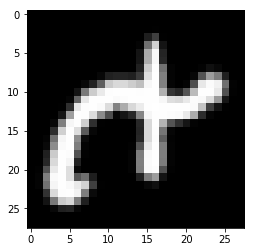

In [9]:
sample = X_train.loc[28]
plt.imshow(sample.values.reshape(28, 28), cmap=plt.cm.gray)
# sample.values, sample.shape

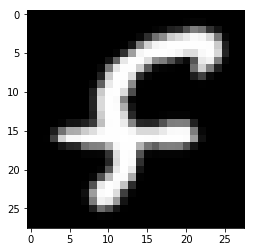

In [10]:
def rotate(image):
    image = image.reshape([HEIGHT, WIDTH])
    image = np.fliplr(image)
    image = np.rot90(image)
    return image

plt.imshow(rotate(sample.values), cmap=plt.cm.gray)

In [11]:
X_train = np.apply_along_axis(rotate, 1, X_train.values)
X_test = np.apply_along_axis(rotate, 1, X_test.values)

In [12]:
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

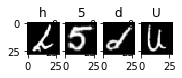

In [13]:
for i in range(100, 104):
    plt.subplot(390 + (i+1))
    plt.imshow(X_train[i], cmap=plt.cm.gray)
    plt.title(chr(mapping[y_train[i]]))
#     print(X_train[i])

In [14]:
number_of_classes = y_train.nunique()

# One Hot Encoding
y_train = np_utils.to_categorical(y_train, number_of_classes)
y_test = np_utils.to_categorical(y_test, number_of_classes)

y_train.shape, y_test.shape

((112799, 47), (18799, 47))

In [15]:
# Reshape train image for CNN input
# Tensorflow (batch, width, height, channels)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [16]:
# partition to train and val
X_train, X_val, y_train, y_val = train_test_split(X_train, 
                                                  y_train, 
                                                  test_size= 0.10, 
                                                  random_state=88)

## LeNet 5 Architecture
![lenet5structure](https://www.researchgate.net/profile/Yiren_Zhou/publication/312170477/figure/fig1/AS:448817725218816@1484017892071/Structure-of-LeNet-5.png)

In [17]:
# model = Sequential()

# model.add(layers.Conv2D(filters=6, kernel_size=(3, 3), activation='relu', input_shape=(28,28,1)))
# model.add(layers.AveragePooling2D())

# model.add(layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu'))
# model.add(layers.AveragePooling2D())

# model.add(layers.Flatten())

# model.add(layers.Dense(units=120, activation='relu'))

# model.add(layers.Dense(units=84, activation='relu'))

# model.add(layers.Dense(units=47, activation = 'softmax'))

# LeNet-5 Best Submision
model = Sequential()
model.add(layers.Conv2D(filters=32, kernel_size=(5,5), padding='same', activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPool2D(strides=2))
model.add(layers.Conv2D(filters=48, kernel_size=(5,5), padding='valid', activation='relu'))
model.add(layers.MaxPool2D(strides=2))
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(84, activation='relu'))
model.add(layers.Dense(47, activation='softmax'))

In [18]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 28, 28, 32)        832       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 14, 14, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 10, 10, 48)        38448     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 5, 5, 48)          0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 1200)              0         
_________________________________________________________________
dense_1 (Dense)              (None, 256)               307456    
_________________________________________________________________
dense_2 (Dense)              (None, 84)               

In [19]:
model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

In [20]:
history = model.fit(X_train,
                    y_train, 
                    epochs=10, 
                    batch_size=16, 
                    verbose=2, 
                    validation_data=(X_val, y_val),
                    callbacks=[TQDMNotebookCallback()])

Train on 101519 samples, validate on 11280 samples


Epoch 1/10


 - 27s - loss: 1.0731 - accuracy: 0.6820 - val_loss: 0.5522 - val_accuracy: 0.8125
Epoch 2/10


 - 26s - loss: 0.4818 - accuracy: 0.8352 - val_loss: 0.4511 - val_accuracy: 0.8387
Epoch 3/10


 - 26s - loss: 0.4053 - accuracy: 0.8568 - val_loss: 0.4195 - val_accuracy: 0.8543
Epoch 4/10


...

 - 26s - loss: 0.3144 - accuracy: 0.8841 - val_loss: 0.3826 - val_accuracy: 0.8656
Epoch 7/10


 - 26s - loss: 0.2971 - accuracy: 0.8895 - val_loss: 0.3714 - val_accuracy: 0.8684
Epoch 8/10


 - 26s - loss: 0.2817 - accuracy: 0.8934 - val_loss: 0.3637 - val_accuracy: 0.8709
Epoch 9/10


 - 26s - loss: 0.2687 - accuracy: 0.8979 - val_loss: 0.3742 - val_accuracy: 0.8697
Epoch 10/10


 - 26s - loss: 0.2559 - accuracy: 0.9017 - val_loss: 0.3713 - val_accuracy: 0.8711



In [21]:
# plot accuracy and loss
def plotgraph(epochs, acc, val_acc):
    # Plot training & validation accuracy values
    plt.plot(epochs, acc, 'b')
    plt.plot(epochs, val_acc, 'r')
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Val'], loc='upper left')
    plt.show()

In [22]:
history.history

{'val_loss': [0.5521548577339936,
  0.4511446953295393,
  0.41946757054815054,
  0.4018498927169869,
  0.3988326477058602,
  0.3826198057872606,
  0.3714463383434935,
  0.363693696031915,
  0.3741960091648478,
  0.3713174604434282],
 'val_accuracy': [0.8125,
  0.8387411236763,
  0.8542553186416626,
  0.8578900694847107,
  0.8579787015914917,
  0.8656028509140015,
  0.8684397339820862,
  0.8709219694137573,
  0.8696808218955994,
  0.8710992932319641],
 'loss': [1.0731431457718867,
  0.4817500701756773,
  0.4052599708964732,
  0.36373038001336566,
  0.33664654357590856,
  0.3144227956145916,
  0.2971304687469125,
  0.2816903157441636,
  0.2687261689486499,
  0.255882529410205],
 'accuracy': [0.6820398,
  0.8351934,
  0.8568248,
  0.86962044,
  0.87699836,
  0.88405126,
  0.8894788,
  0.89343864,
  0.8979107,
  0.9017327]}

In [23]:
#%%
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1,len(acc)+1)

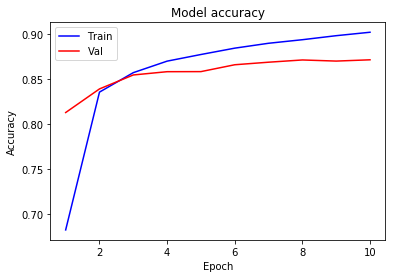

In [24]:
# Accuracy curve
plotgraph(epochs, acc, val_acc)

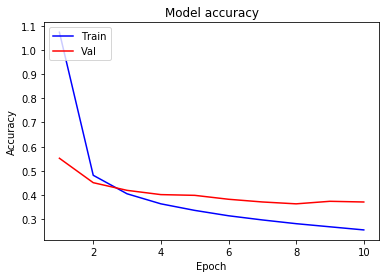

In [25]:
# loss curve
plotgraph(epochs, loss, val_loss)

In [26]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

In [27]:
y_pred.shape

(18799, 47)

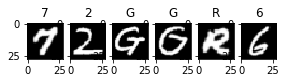

In [28]:
for i in range(10, 16):
    plt.subplot(380 + (i%10+1))
    plt.imshow(X_test[i].reshape(28, 28), cmap=plt.cm.gray)
    plt.title(chr(mapping[y_pred[i].argmax()]))

In [29]:
model.save('character_recognizer.h5')

In [30]:
model.evaluate(X_test, y_test)

18799/18799 [==============================] - ETA:  - ETA:  - ETA:  - ETA:  - ETA:  - ETA:  - ETA:  - ETA:  - ETA:  - ETA:  - ETA:  - ETA:  - ETA:  - ETA:  - ETA:  - ETA:  - ETA:  - ETA:  - ETA:  - ETA:  - ETA:  - ETA:  - ETA:  - ETA:  - ETA:  - 1s 68us/step


[0.38025558427474787, 0.8700994849205017]